In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [7]:
from tensorflow.keras.applications import ResNet50, DenseNet121
from keras.applications import EfficientNetB0 # Use the Keras 3 native import

# Import their specific preprocessing functions
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
# ---

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# --- Step 2: Load Processed Hyperspectral Data ---
print("Loading processed hyperspectral (PCA-reduced) data...")
X_train_hyper = np.load("../data/processed/X_train_hyper.npy")
y_train_hyper = np.load("../data/processed/y_train_hyper.npy")
X_test_hyper = np.load("../data/processed/X_test_hyper.npy")
y_test_hyper = np.load("../data/processed/y_test_hyper.npy")
print(f"X_train_hyper shape: {X_train_hyper.shape}")
print("Data loaded.")

Loading processed hyperspectral (PCA-reduced) data...
X_train_hyper shape: (1272, 128, 128, 3)
Data loaded.


In [3]:
# --- Step 3: Encode Labels ---
print("Encoding labels (0.0, 0.5, 1.0) -> (0, 1, 2)...")
hyper_le = LabelEncoder()
y_train_encoded = hyper_le.fit_transform(y_train_hyper)
y_test_encoded = hyper_le.transform(y_test_hyper)
HYPER_NUM_CLASSES = len(hyper_le.classes_)
hyper_class_names = [str(c) for c in hyper_le.classes_]
print(f"Found {HYPER_NUM_CLASSES} classes: {hyper_class_names}")
with open('../models/hyper_label_encoder.pkl', 'wb') as f:
    pickle.dump(hyper_le, f)

Encoding labels (0.0, 0.5, 1.0) -> (0, 1, 2)...
Found 3 classes: ['0.0', '0.5', '1.0']


In [4]:
# --- Step 4: Define Reusable Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, min_lr=1e-6)
]

In [15]:
# --- Step 5: Helper Function to Build Models ---
# This is the correct version that gave 88% accuracy

def build_model(model_name, num_classes):
    if model_name == "ResNet50":
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
        preprocess_fn = resnet_preprocess
    elif model_name == "DenseNet121":
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
        preprocess_fn = dense_preprocess
    
    base_model.trainable = False
    
    model = models.Sequential([
        # Define the input shape
        layers.Input(shape=(128, 128, 3)),
        
        # --- THIS IS THE CORRECT LOGIC ---
        # 1. Convert our [0, 1] data back to [0, 255]
        layers.Rescaling(255.0),
        # 2. NOW apply the model-specific preprocessing
        layers.Lambda(preprocess_fn),
        
        # Now the data is in the correct format
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [16]:
# --- Step 6: Train and Compare All Models ---

# We are only training the models that work
models_to_train = ["ResNet50", "DenseNet121"]

all_models = {}
all_histories = {}

for model_name in models_to_train:
    print(f"\n--- Training Model: {model_name} ---")
    
    # This will use the "build_model" function from Step 5
    model = build_model(model_name, HYPER_NUM_CLASSES)
    
    history = model.fit(
        X_train_hyper, y_train_encoded,
        batch_size=32,
        epochs=20,
        validation_data=(X_test_hyper, y_test_encoded),
        callbacks=callbacks
    )
    all_models[model_name] = model
    all_histories[model_name] = history


--- Training Model: ResNet50 ---
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 818ms/step - accuracy: 0.5440 - loss: 1.0772 - val_accuracy: 0.7044 - val_loss: 0.7502 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.6291 - loss: 0.8765
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 800ms/step - accuracy: 0.6572 - loss: 0.8201 - val_accuracy: 0.7264 - val_loss: 0.7118 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 774ms/step - accuracy: 0.6942 - loss: 0.7721 - val_accuracy: 0.7390 - val_loss: 0.6990 - learning_rate: 2.0000e-05
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

--- Training Model: DenseNet121 ---
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 876ms/step - accuracy: 0.4316 - loss: 1.4805 - val_accuracy: 0.6321 - val_loss: 0.8824 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.


--- MODEL EVALUATION ---

--- Results for ResNet50 ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 749ms/step
              precision    recall  f1-score   support

         0.0       0.66      0.78      0.72       119
         0.5       0.00      0.00      0.00        34
         1.0       0.74      0.79      0.77       165

    accuracy                           0.70       318
   macro avg       0.47      0.53      0.49       318
weighted avg       0.63      0.70      0.67       318



C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


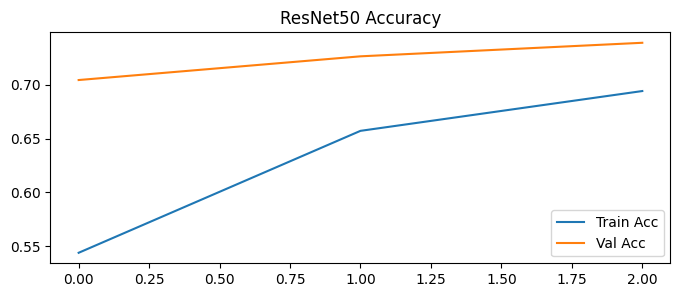


--- Results for DenseNet121 ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
              precision    recall  f1-score   support

         0.0       0.57      0.69      0.62       119
         0.5       0.00      0.00      0.00        34
         1.0       0.69      0.72      0.70       165

    accuracy                           0.63       318
   macro avg       0.42      0.47      0.44       318
weighted avg       0.57      0.63      0.60       318



C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


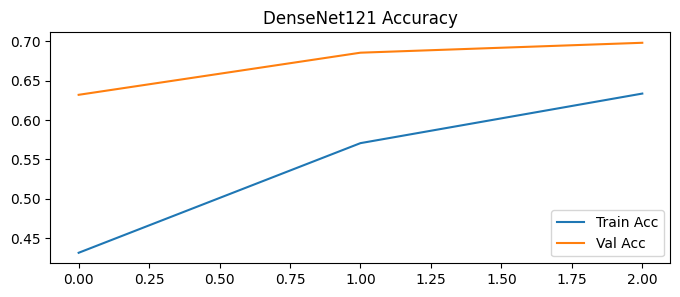


--- FINAL MODEL COMPARISON ---
         Model  Best Validation Accuracy
0     ResNet50                     73.90
1  DenseNet121                     69.81

Saving the best model (ResNet50) to '../models/nutrient_hyper_model.h5'
Model saved.


In [18]:
results = []
print("\n--- MODEL EVALUATION ---")

# --- THIS IS THE FIX ---
# We loop through all_models, which has the 'name' and 'model'
for name, model in all_models.items():
    # Then we get the matching 'history' from the all_histories dict
    history = all_histories[name]
    # ---
    
    print(f"\n--- Results for {name} ---")
    y_pred_probs = model.predict(X_test_hyper)
    y_pred = np.argmax(y_pred_probs, axis=1)
    print(classification_report(y_test_encoded, y_pred, target_names=hyper_class_names))
    
    plt.figure(figsize=(8, 3))
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{name} Accuracy')
    plt.legend()
    plt.show()
    
    val_acc = max(history.history['val_accuracy'])
    results.append({
        "Model": name,
        "Best Validation Accuracy": val_acc
    })

print("\n--- FINAL MODEL COMPARISON ---")
df_results = pd.DataFrame(results).sort_values(by="Best Validation Accuracy", ascending=False)
df_results['Best Validation Accuracy'] = (df_results['Best Validation Accuracy'] * 100).round(2)
print(df_results)

# Save the best model
best_model_name = df_results.iloc[0]['Model']
best_model_obj = all_models[best_model_name]
print(f"\nSaving the best model ({best_model_name}) to '../models/nutrient_hyper_model.h5'")
best_model_obj.save("../models/nutrient_hyper_model.h5")
print("Model saved.")